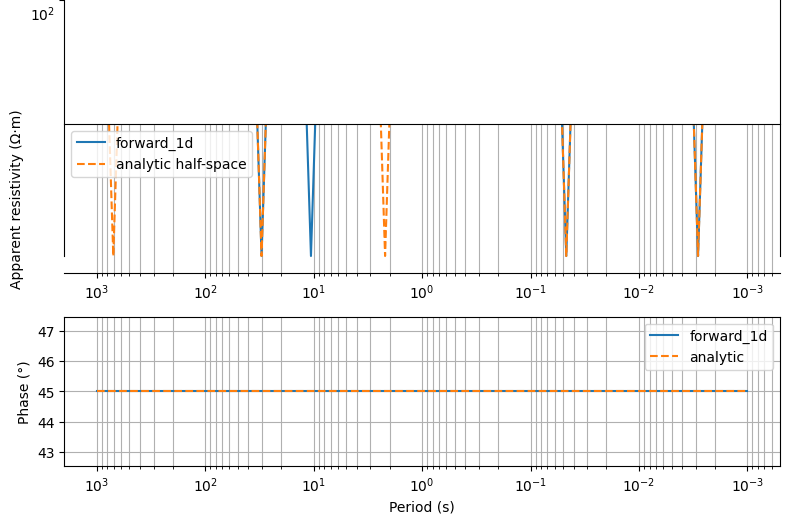

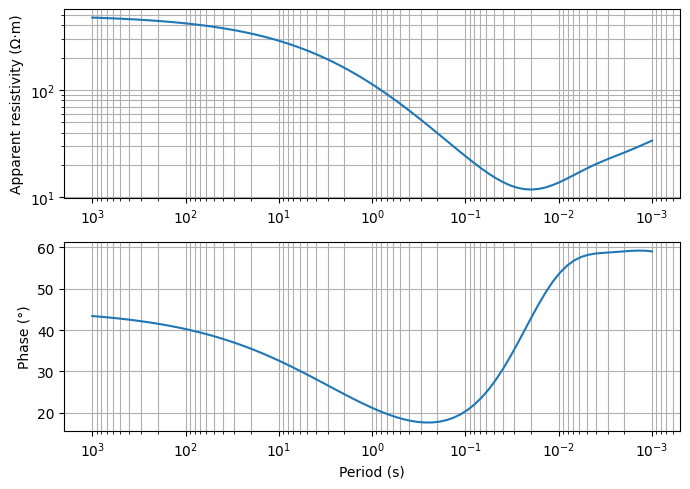

In [1]:
import numpy as np
import matplotlib.pyplot as plt

mu0 = 4 * np.pi * 1e-7

def layer_impedance(rho, omega):
    """Intrinsic impedance Z_j = sqrt(i*w*mu0 / sigma) = sqrt(i*w*mu0*rho)"""
    sigma = 1.0 / rho
    return np.sqrt(1j * omega * mu0 / sigma)

def prop_const(rho, omega):
    """Propagation constant gamma = sqrt(i*w*mu0*sigma)"""
    sigma = 1.0 / rho
    return np.sqrt(1j * omega * mu0 * sigma)

def forward_1d(layers, freqs):
    """
    layers: list of dicts [{'rho': value, 'thk': value or None}, ...]
            last layer must have 'thk' = None to indicate half-space
    freqs: 1D array of frequencies (Hz)
    
    Returns:
      Zs: complex array of surface impedance for each frequency
      rho_app: apparent resistivity array
      phase_deg: phase in degrees
    """
    omega = 2 * np.pi * np.asarray(freqs)
    nf = len(omega)
    Zs = np.zeros(nf, dtype=complex)
    
    # Precompute layer properties
    rhos = [layer['rho'] for layer in layers]
    thks = [layer['thk'] for layer in layers]
    
   
    for i, w in enumerate(omega):
        idx = len(layers) - 1
        rho_bot = rhos[idx]
        Z_down = layer_impedance(rho_bot, w)  
        
        for j in range(idx-1, -1, -1):
            rho_j = rhos[j]
            d_j = thks[j]
            Z_j = layer_impedance(rho_j, w)
            gamma_j = prop_const(rho_j, w)
            if d_j is None:
                Z_in = Z_j
            else:
                td = np.tanh(gamma_j * d_j)
                Z_in = Z_j * (Z_down + Z_j * td) / (Z_j + Z_down * td)
            Z_down = Z_in
        Zs[i] = Z_down
    
    rho_app = (np.abs(Zs)**2) / (mu0 * 2 * np.pi * np.asarray(freqs))
    phase_deg = np.rad2deg(np.angle(Zs))
    return Zs, rho_app, phase_deg



# 1) Half-space only test: one-layer list with thk=None
freqs = np.logspace(-3, 3, 80)  
layers_half = [{'rho': 100.0, 'thk': None}]  
Zs_half, rho_half, phase_half = forward_1d(layers_half, freqs)


# Analytic half-space impedance: Z = sqrt(i*w*mu0*rho)
omega = 2*np.pi*freqs
Z_analytic = np.sqrt(1j * omega * mu0 * 100.0)
rho_analytic = np.abs(Z_analytic)**2 / (mu0 * omega)
phase_analytic = np.rad2deg(np.angle(Z_analytic))

# Plot comparison 
plt.figure(figsize=(8,5))
plt.subplot(2,1,1)
plt.loglog(1/freqs, rho_half, label='forward_1d')
plt.loglog(1/freqs, rho_analytic, '--', label='analytic half-space')
plt.gca().invert_xaxis()
plt.ylabel('Apparent resistivity (Ω·m)')
plt.legend()
plt.grid(which='both')

plt.subplot(2,1,2)
plt.semilogx(1/freqs, phase_half, label='forward_1d')
plt.semilogx(1/freqs, phase_analytic, '--', label='analytic')
plt.gca().invert_xaxis()
plt.xlabel('Period (s)')
plt.ylabel('Phase (°)')
plt.legend()
plt.grid(which='both')
plt.tight_layout()
plt.show()

# 2) Example 3-layer model
layers_example = [
    {'rho': 50.0, 'thk': 50.0},    
    {'rho': 10.0, 'thk': 200.0},   
    {'rho': 500.0, 'thk': None}    
]
Zs_ex, rho_ex, phase_ex = forward_1d(layers_example, freqs)

plt.figure(figsize=(7,5))
plt.subplot(2,1,1)
plt.loglog(1/freqs, rho_ex)
plt.gca().invert_xaxis()
plt.ylabel('Apparent resistivity (Ω·m)')
plt.grid(which='both')

plt.subplot(2,1,2)
plt.semilogx(1/freqs, phase_ex)
plt.gca().invert_xaxis()
plt.xlabel('Period (s)')
plt.ylabel('Phase (°)')
plt.grid(which='both')
plt.tight_layout()
plt.show()


In [2]:
from mt_metadata.transfer_functions import TF

edi_obj = TF()
edi_obj.read(fn="./BVV170923.edi")


freq = np.array(edi_obj.frequency)
Z = np.array(edi_obj.impedance.data[:, 0, 1])

print("Z shape:", Z.shape)
print("Frequency range (Hz):", freq.min(), "-", freq.max())


Z shape: (61,)
Frequency range (Hz): 0.0008392299999999999 - 230.47


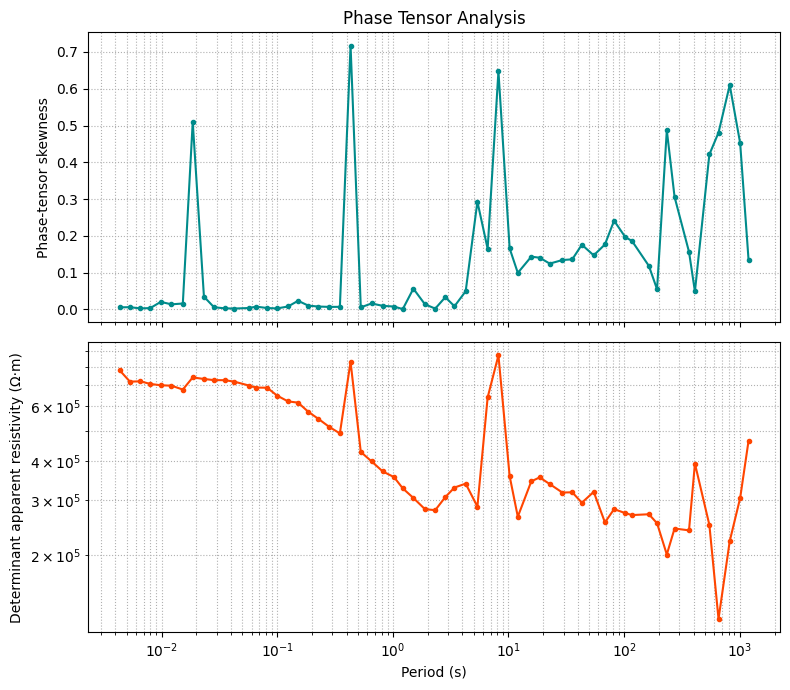

--- Skewness Interpretation ---
Number of frequencies with skew > 0.05: 29 / 61
Number of frequencies with skew > 0.1: 26 / 61
Number of frequencies with skew > 0.3: 9 / 61
(Low skew suggests 1D/2D geology; high skew suggests 3D geology or noise)


In [3]:
from mt_metadata.transfer_functions import TF
import numpy as np
import matplotlib.pyplot as plt


edi_obj = TF()
edi_obj.read(fn="BVV170923.edi")


freq = np.array(edi_obj.frequency)
Z = np.array(edi_obj.impedance.data)




def det_apparent_resistivity(Z_matrix, freq_val):
    """Calculates apparent resistivity from the determinant of a 2x2 impedance tensor."""
    Zd = np.linalg.det(Z_matrix)
    mu0 = 4 * np.pi * 1e-7
    omega = 2 * np.pi * freq_val
    rho_det = np.abs(Zd) / (mu0 * omega)
    return rho_det

def phase_tensor(Z_matrix):
    """Calculates the phase tensor Phi = (Re Z)^-1 * (Im Z)."""
    Re = np.real(Z_matrix)
    Im = np.imag(Z_matrix)
    
    try:
        Re_inv = np.linalg.inv(Re)
    except np.linalg.LinAlgError:
        Re_inv = np.linalg.pinv(Re)
        
    Phi = Re_inv.dot(Im)
    return Phi  

def phase_tensor_skewness(Phi):
    """Calculates the skewness of the phase tensor."""
    S = 0.5 * (Phi + Phi.T)
    A = 0.5 * (Phi - Phi.T)
    
    ns = np.linalg.norm(S, ord='fro')
    na = np.linalg.norm(A, ord='fro')
    
   
    skew = na / (ns + 1e-18) 
    return skew, S, A



Z_all = Z  
freqs = freq
skews = []
rho_det = np.zeros(len(freqs))


for i, f in enumerate(freqs):
    Zi = Z_all[i, :, :]  
    
    rho_det[i] = det_apparent_resistivity(Zi, f)
    Phi = phase_tensor(Zi)
    skew, S, A = phase_tensor_skewness(Phi)
    skews.append(skew)

skews = np.array(skews)



fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

# Plot 1: Phase Tensor Skewness vs. Period
ax1.semilogx(1/freqs, skews, '.-', color='darkcyan')
ax1.set_ylabel('Phase-tensor skewness')
ax1.grid(True, which='both', linestyle=':')
ax1.set_title('Phase Tensor Analysis')
ax1.invert_xaxis()

# Plot 2: Determinant Apparent Resistivity vs. Period
ax2.loglog(1/freqs, rho_det, '.-', color='orangered')
ax2.set_ylabel('Determinant apparent resistivity (Ω·m)')
ax2.set_xlabel('Period (s)')
ax2.grid(True, which='both', linestyle=':')
ax2.invert_xaxis()

plt.tight_layout()
plt.show()


print("--- Skewness Interpretation ---")
for thr in [0.05, 0.1, 0.3]:
    count = np.sum(skews > thr)
    print(f"Number of frequencies with skew > {thr}: {count} / {len(skews)}")
print("(Low skew suggests 1D/2D geology; high skew suggests 3D geology or noise)")


Best-fit rho2, thk2: 10.481131341546858 206.12244897959184


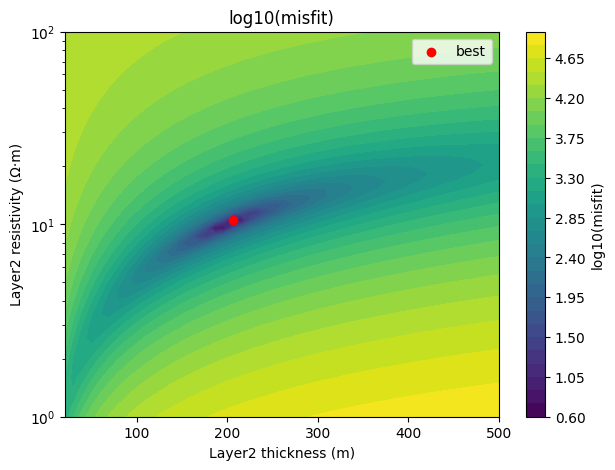

In [4]:
# assume forward_1d is defined in your notebook (from earlier code)
freqs = np.logspace(-3, 3, 80)

# true model (from earlier example)
true_layers = [
    {'rho': 50.0, 'thk': 50.0},
    {'rho': 10.0, 'thk': 200.0},
    {'rho': 500.0, 'thk': None}
]
_, rho_true, phase_true = forward_1d(true_layers, freqs)

# set search ranges
rho2_vals = np.logspace(np.log10(1.0), np.log10(100.0), 50)  
thk2_vals = np.linspace(20, 500, 50)                        

misfit = np.zeros((len(rho2_vals), len(thk2_vals)))

sigma_logrho = 0.1 
sigma_phase = 2.0  

for i, r2 in enumerate(rho2_vals):
    for j, t2 in enumerate(thk2_vals):
        model = [
            {'rho': 50.0, 'thk': 50.0},     
            {'rho': r2,   'thk': t2},
            {'rho': 500.0, 'thk': None}
        ]
        _, rho_syn, phi_syn = forward_1d(model, freqs)
        e_rho = (np.log(rho_true) - np.log(rho_syn)) / sigma_logrho
        e_phi = (phase_true - phi_syn) / sigma_phase
        misfit[i, j] = np.sum(e_rho**2) + np.sum(e_phi**2)

# find best fit
imin, jmin = np.unravel_index(np.argmin(misfit), misfit.shape)
best_rho2 = rho2_vals[imin]
best_thk2 = thk2_vals[jmin]
print("Best-fit rho2, thk2:", best_rho2, best_thk2)

# Plot misfit map
plt.figure(figsize=(7,5))
plt.contourf(thk2_vals, rho2_vals, np.log10(misfit+1e-12), 30, cmap='viridis')
plt.xscale('linear')
plt.yscale('log')
plt.xlabel('Layer2 thickness (m)')
plt.ylabel('Layer2 resistivity (Ω·m)')
plt.title('log10(misfit)')
plt.colorbar(label='log10(misfit)')
plt.scatter([best_thk2], [best_rho2], color='red', label='best')
plt.legend()
plt.show()
